# 🇻🇳 BamiBERT SOTA (Exp006) — Đánh Giá Tích Hợp Đề Xuất 3: Context Window Expansion
### Môn học: CS221 — Xử lý Ngôn ngữ Tự nhiên (Natural Language Processing)
**Đồ án:** Vietnamese Fact-Checking with Evidence Retrieval & NLI Verification

---

### Bối cảnh & Động lực Thực nghiệm:
Trong notebook `04_fact_reranking.ipynb` và `bamibert_reranking.ipynb`, mô hình **BamiBERT Exp006 SOTA** khi chạy trên bằng chứng trích xuất 1 câu đơn lẻ từ Fact-aware Reranker chỉ đạt **62.42% Macro-F1**, sụt giảm nghiêm trọng so với khi có bằng chứng vàng chuẩn (**81.42% Macro-F1** — hiện tượng **Reality Drop**).

**Nguyên nhân cốt lõi:** Hiện tượng **Context Starvation (Đói ngữ cảnh)**:
- Một câu đơn lẻ thường chứa các đại từ thay thế (*"ông", "bà", "vị này"*), khiến mô hình NLI không xác định được chủ thể của hành động.
- Nhiều tuyên bố phức tạp đòi hỏi phải xâu chuỗi thông tin từ 2 câu liên tiếp trong văn bản gốc.

### Mục tiêu của Notebook này:
1. **Triển khai Đề xuất 3 trên BamiBERT SOTA:**
   - **Đề xuất 3A (Top-2 Concatenation):** Ghép 2 câu ứng viên có điểm số cao nhất từ bộ tái xếp hạng.
   - **Đề xuất 3B (Sliding Window $\pm 1$):** Ghép câu liền trước và liền sau từ bài báo gốc để khôi phục quan hệ đồng tham chiếu.
   - **Đề xuất 1 (DPR Hybrid Top-1):** Câu bằng chứng tối ưu từ mô hình Contrastive DPR Bi-Encoder.
2. **Đo lường Định lượng:** So sánh Accuracy, Macro-F1, Precision, Recall và định lượng mức độ thu hẹp khoảng cách Reality Gap.
3. **Phân tích Định tính Chuyên sâu:** Phân tích các ca thực tế được "giải cứu" thành công nhờ mở rộng ngữ cảnh.

In [1]:
import os
import sys
import json
import time
from pathlib import Path

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from transformers import AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score, precision_score, recall_score

# Cấu hình pandas và seaborn
pd.set_option("display.max_colwidth", 150)
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams.update({"font.sans-serif": "DejaVu Sans", "figure.dpi": 150})

# Đường dẫn tương đối từ notebooks/models/bamibert/ về project root
PROJECT_ROOT = Path("../../..").resolve()
RETRIEVAL_DATA_DIR = PROJECT_ROOT / "data/processed/retrieval"
BAMIBERT_CKPT_DIR = PROJECT_ROOT / "notebooks/models/bamibert/outputs/bamibert/experiments/Exp006_PrefixPrompt_SOTA/best_model"

# Thiết bị tăng tốc phần cứng
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"✓ Project Root: {PROJECT_ROOT}")
print(f"✓ Retrieval Data Dir: {RETRIEVAL_DATA_DIR}")
print(f"✓ Checkpoint BamiBERT SOTA: {BAMIBERT_CKPT_DIR}")
print(f"✓ Hardware Acceleration: {device}")

✓ Project Root: /Users/mivu/Documents/Artificial Intelligence/CS221-NLP/Project-NLP-Fact-Checking
✓ Retrieval Data Dir: /Users/mivu/Documents/Artificial Intelligence/CS221-NLP/Project-NLP-Fact-Checking/data/processed/retrieval
✓ Checkpoint BamiBERT SOTA: /Users/mivu/Documents/Artificial Intelligence/CS221-NLP/Project-NLP-Fact-Checking/notebooks/models/bamibert/outputs/bamibert/experiments/Exp006_PrefixPrompt_SOTA/best_model
✓ Hardware Acceleration: mps


## 1. Nạp Các Tập Dữ Liệu Bằng Chứng Thực Nghiệm
Nạp 6 kịch bản bằng chứng trên toàn bộ 723 phát biểu thuộc tập Dev:
1. `A. Gold Evidence (Upper-bound)`: Bằng chứng vàng lý tưởng.
2. `B. BM25 Top-1 (Keyword)`: Bằng chứng từ khóa tốt nhất.
3. `C. Fact-aware Reranked Top-1`: Bằng chứng từ bộ tái xếp hạng heuristic.
4. `D. Đề xuất 3B: Sliding Window (±1)`: Mở rộng ngữ cảnh lân cận trong văn bản gốc.
5. `E. Đề xuất 3A: Top-2 Concatenated`: Ghép 2 câu bằng chứng điểm cao nhất.
6. `F. Đề xuất 1: DPR Hybrid Top-1`: Bằng chứng từ mô hình Contrastive Bi-Encoder.

In [2]:
# Đọc tập Dev Gold Evidence trực tiếp từ dữ liệu gốc
dev_cleaned = pd.read_csv(PROJECT_ROOT / "data/processed/common_cleaned/vifactcheck_dev_common_cleaned.csv")
df_gold = pd.DataFrame({
    "claim_id": [f"dev_{i}" for i in dev_cleaned["index"]],
    "claim_index": dev_cleaned["index"],
    "statement": dev_cleaned["Statement"],
    "evidence": dev_cleaned["Evidence"].fillna(""),
    "label": dev_cleaned["labels"]
})

retrieval_scenarios = {
    "B. BM25 Top-1 (Keyword)": RETRIEVAL_DATA_DIR / "nli_input_bm25.csv",
    "C. Fact-aware Reranked Top-1": RETRIEVAL_DATA_DIR / "nli_input_reranked.csv",
    "D. Đề xuất 3B: Sliding Window (±1)": RETRIEVAL_DATA_DIR / "nli_input_window_expanded.csv",
    "E. Đề xuất 3A: Top-2 Concatenated": RETRIEVAL_DATA_DIR / "nli_input_top2_expanded.csv"
}

dfs = {"A. Gold Evidence (Lý tưởng)": df_gold}
print(f"✓ Nạp thành công [A. Gold Evidence (Lý tưởng)]: {len(df_gold)} mẫu")

for name, path in retrieval_scenarios.items():
    if not path.exists():
        raise FileNotFoundError(f"Chưa tìm thấy file: {path}")
    df = pd.read_csv(path)
    dfs[name] = df
    print(f"✓ Nạp thành công [{name}]: {len(df)} mẫu | Cột: {list(df.columns)}")


✓ Nạp thành công [A. Gold Evidence (Lý tưởng)]: 723 mẫu
✓ Nạp thành công [B. BM25 Top-1 (Keyword)]: 723 mẫu
✓ Nạp thành công [C. Fact-aware Reranked Top-1]: 723 mẫu
✓ Nạp thành công [D. Đề xuất 3B: Sliding Window (±1)]: 723 mẫu
✓ Nạp thành công [E. Đề xuất 3A: Top-2 Concatenated]: 723 mẫu
✓ Nạp thành công [F. Đề xuất 1: DPR Hybrid Top-1]: 723 mẫu

Độ dài trung bình (số từ) của bằng chứng qua từng kịch bản:
  • A. Gold Evidence (Lý tưởng)        : 43.3 từ/mẫu (Max: 201)
  • B. BM25 Top-1 (Keyword)            : 45.4 từ/mẫu (Max: 209)
  • C. Fact-aware Reranked Top-1       : 45.5 từ/mẫu (Max: 209)
  • D. Đề xuất 3B: Sliding Window (±1) : 116.6 từ/mẫu (Max: 326)
  • E. Đề xuất 3A: Top-2 Concatenated  : 91.9 từ/mẫu (Max: 279)
  • F. Đề xuất 1: DPR Hybrid Top-1     : 32.4 từ/mẫu (Max: 209)


## 2. Nạp Tokenizer & Mô hình BamiBERT Exp006 SOTA
Áp dụng cấu trúc tiền tố ngữ nghĩa (*Semantic Prefix Prompting*) chuẩn của thực nghiệm Exp006:
$$\\text{Tuyên bố: } [Statement] \\quad \\texttt{</s></s>} \\quad \\text{Bằng chứng: } [Evidence]$$

In [3]:
print("Đang nạp Tokenizer và Mô hình BamiBERT Exp006 SOTA...")
tokenizer = AutoTokenizer.from_pretrained(BAMIBERT_CKPT_DIR)
model = AutoModelForSequenceClassification.from_pretrained(BAMIBERT_CKPT_DIR)
model.to(device)
model.eval()

total_params = sum(p.numel() for p in model.parameters())
print(f"✓ Nạp mô hình thành công! Tổng số tham số: {total_params:,}")
print(f"✓ Bảng ánh xạ nhãn: {model.config.id2label}")

Đang nạp Tokenizer và Mô hình BamiBERT Exp006 SOTA...


✓ Nạp mô hình thành công! Tổng số tham số: 102,953,475
✓ Bảng ánh xạ nhãn: {0: 'SUPPORTED', 1: 'REFUTED', 2: 'NEI'}


## 3. Hàm Đánh Giá Suy Luận Tối Ưu (Batched Inference)

In [4]:
from torch.utils.data import DataLoader, TensorDataset

def evaluate_bamibert_nli(df_input, split_name="Unknown", batch_size=32, max_length=256):
    claims = [f"Tuyên bố: {str(s).strip()}" for s in df_input["statement"]]
    evidences = [f"Bằng chứng: {str(e).strip()}" for e in df_input["evidence"]]
    labels = df_input["label"].astype(int).tolist()
    
    enc = tokenizer(claims, evidences, padding=True, truncation=True, max_length=max_length, return_tensors="pt")
    ds = TensorDataset(enc["input_ids"], enc["attention_mask"], torch.tensor(labels, dtype=torch.long))
    loader = DataLoader(ds, batch_size=batch_size, shuffle=False)
    
    all_preds, all_probs, all_targets = [], [], []
    t0 = time.time()
    with torch.no_grad():
        for b_ids, b_mask, b_y in loader:
            b_ids = b_ids.to(device)
            b_mask = b_mask.to(device)
            out = model(input_ids=b_ids, attention_mask=b_mask)
            probs = torch.softmax(out.logits, dim=1).cpu().numpy()
            preds = np.argmax(probs, axis=1)
            all_preds.extend(preds)
            all_probs.extend(probs)
            all_targets.extend(b_y.numpy())
            
    elapsed = time.time() - t0
    y_true = np.array(all_targets)
    y_pred = np.array(all_preds)
    
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average="macro")
    prec_macro = precision_score(y_true, y_pred, average="macro")
    rec_macro = recall_score(y_true, y_pred, average="macro")
    rep = classification_report(y_true, y_pred, target_names=["SUPPORTED", "REFUTED", "NEI"], output_dict=True, zero_division=0)
    
    print(f"✓ [{split_name}] Suy luận: {elapsed:.2f}s | Tốc độ: {len(df_input)/elapsed:.1f} mẫu/s")
    print(f"  • Accuracy: {acc*100:.2f}% | Macro-F1: {f1_macro*100:.2f}%")
    
    return {
        "split_name": split_name,
        "Accuracy": acc,
        "Macro-F1": f1_macro,
        "Macro-Precision": prec_macro,
        "Macro-Recall": rec_macro,
        "y_true": y_true,
        "y_pred": y_pred,
        "y_probs": np.array(all_probs),
        "report": rep
    }

eval_results = {}
for name, df in dfs.items():
    print(f"\n--- Đang đánh giá: {name} ---")
    eval_results[name] = evaluate_bamibert_nli(df, split_name=name)


--- Đang đánh giá: A. Gold Evidence (Lý tưởng) ---


✓ [A. Gold Evidence (Lý tưởng)] Suy luận: 15.59s | Tốc độ: 46.4 mẫu/s
  • Accuracy: 81.05% | Macro-F1: 81.16%

--- Đang đánh giá: B. BM25 Top-1 (Keyword) ---


✓ [B. BM25 Top-1 (Keyword)] Suy luận: 14.80s | Tốc độ: 48.9 mẫu/s
  • Accuracy: 62.52% | Macro-F1: 62.55%

--- Đang đánh giá: C. Fact-aware Reranked Top-1 ---


✓ [C. Fact-aware Reranked Top-1] Suy luận: 15.16s | Tốc độ: 47.7 mẫu/s
  • Accuracy: 62.38% | Macro-F1: 62.42%

--- Đang đánh giá: D. Đề xuất 3B: Sliding Window (±1) ---


✓ [D. Đề xuất 3B: Sliding Window (±1)] Suy luận: 15.44s | Tốc độ: 46.8 mẫu/s
  • Accuracy: 69.29% | Macro-F1: 69.10%

--- Đang đánh giá: E. Đề xuất 3A: Top-2 Concatenated ---


✓ [E. Đề xuất 3A: Top-2 Concatenated] Suy luận: 15.47s | Tốc độ: 46.7 mẫu/s
  • Accuracy: 70.68% | Macro-F1: 70.39%

--- Đang đánh giá: F. Đề xuất 1: DPR Hybrid Top-1 ---


✓ [F. Đề xuất 1: DPR Hybrid Top-1] Suy luận: 15.48s | Tốc độ: 46.7 mẫu/s
  • Accuracy: 68.33% | Macro-F1: 67.91%


## 4. Bảng Tổng Hợp Kết Quả & Độ Tăng Trưởng (Leaderboard)

In [5]:
base_f1 = eval_results["C. Fact-aware Reranked Top-1"]["Macro-F1"]

summary_rows = []
for name, res in eval_results.items():
    diff_f1 = (res["Macro-F1"] - base_f1) * 100
    sign = "+" if diff_f1 > 0 else ""
    summary_rows.append({
        "Kịch bản Bằng chứng": name,
        "Accuracy": f"{res['Accuracy']*100:.2f}%",
        "Macro-F1": f"{res['Macro-F1']*100:.2f}%",
        "Macro-Precision": f"{res['Macro-Precision']*100:.2f}%",
        "Macro-Recall": f"{res['Macro-Recall']*100:.2f}%",
        "Tăng trưởng F1 (vs Rerank Top-1)": f"{sign}{diff_f1:.2f}%" if name != "C. Fact-aware Reranked Top-1" else "0.00% (Mốc gốc)"
    })

summary_df = pd.DataFrame(summary_rows)
print("=" * 100)
print("BẢNG TỔNG HỢP HIỆU NĂNG BAMIBERT EXP006 QUA CÁC PHƯƠNG PHÁP MỞ RỘNG NGỮ CẢNH:")
print("=" * 100)
display(summary_df)

# Lưu kết quả ra CSV
output_csv = RETRIEVAL_DATA_DIR / "bamibert_context_expansion_comparison.csv"
summary_df.to_csv(output_csv, index=False)
print(f"\n✓ Đã lưu bảng kết quả định lượng tại: {output_csv}")

BẢNG TỔNG HỢP HIỆU NĂNG BAMIBERT EXP006 QUA CÁC PHƯƠNG PHÁP MỞ RỘNG NGỮ CẢNH:


,Kịch bản Bằng chứng,Accuracy,Macro-F1,Macro-Precision,Macro-Recall,Tăng trưởng F1 (vs Rerank Top-1)
0,A. Gold Evidence (Lý tưởng),81.05%,81.16%,81.09%,81.29%,+18.74%
1,B. BM25 Top-1 (Keyword),62.52%,62.55%,66.07%,63.20%,+0.13%
2,C. Fact-aware Reranked Top-1,62.38%,62.42%,66.04%,63.07%,0.00% (Mốc gốc)
3,D. Đề xuất 3B: Sliding Window (±1),69.29%,69.10%,70.72%,68.86%,+6.68%
4,E. Đề xuất 3A: Top-2 Concatenated,70.68%,70.39%,71.17%,70.28%,+7.97%
5,F. Đề xuất 1: DPR Hybrid Top-1,68.33%,67.91%,73.17%,69.39%,+5.50%



✓ Đã lưu bảng kết quả định lượng tại: /Users/mivu/Documents/Artificial Intelligence/CS221-NLP/Project-NLP-Fact-Checking/data/processed/retrieval/bamibert_context_expansion_comparison.csv


## 5. Trực Quan Hóa Ma Trận Nhầm Lẫn (Confusion Matrices)

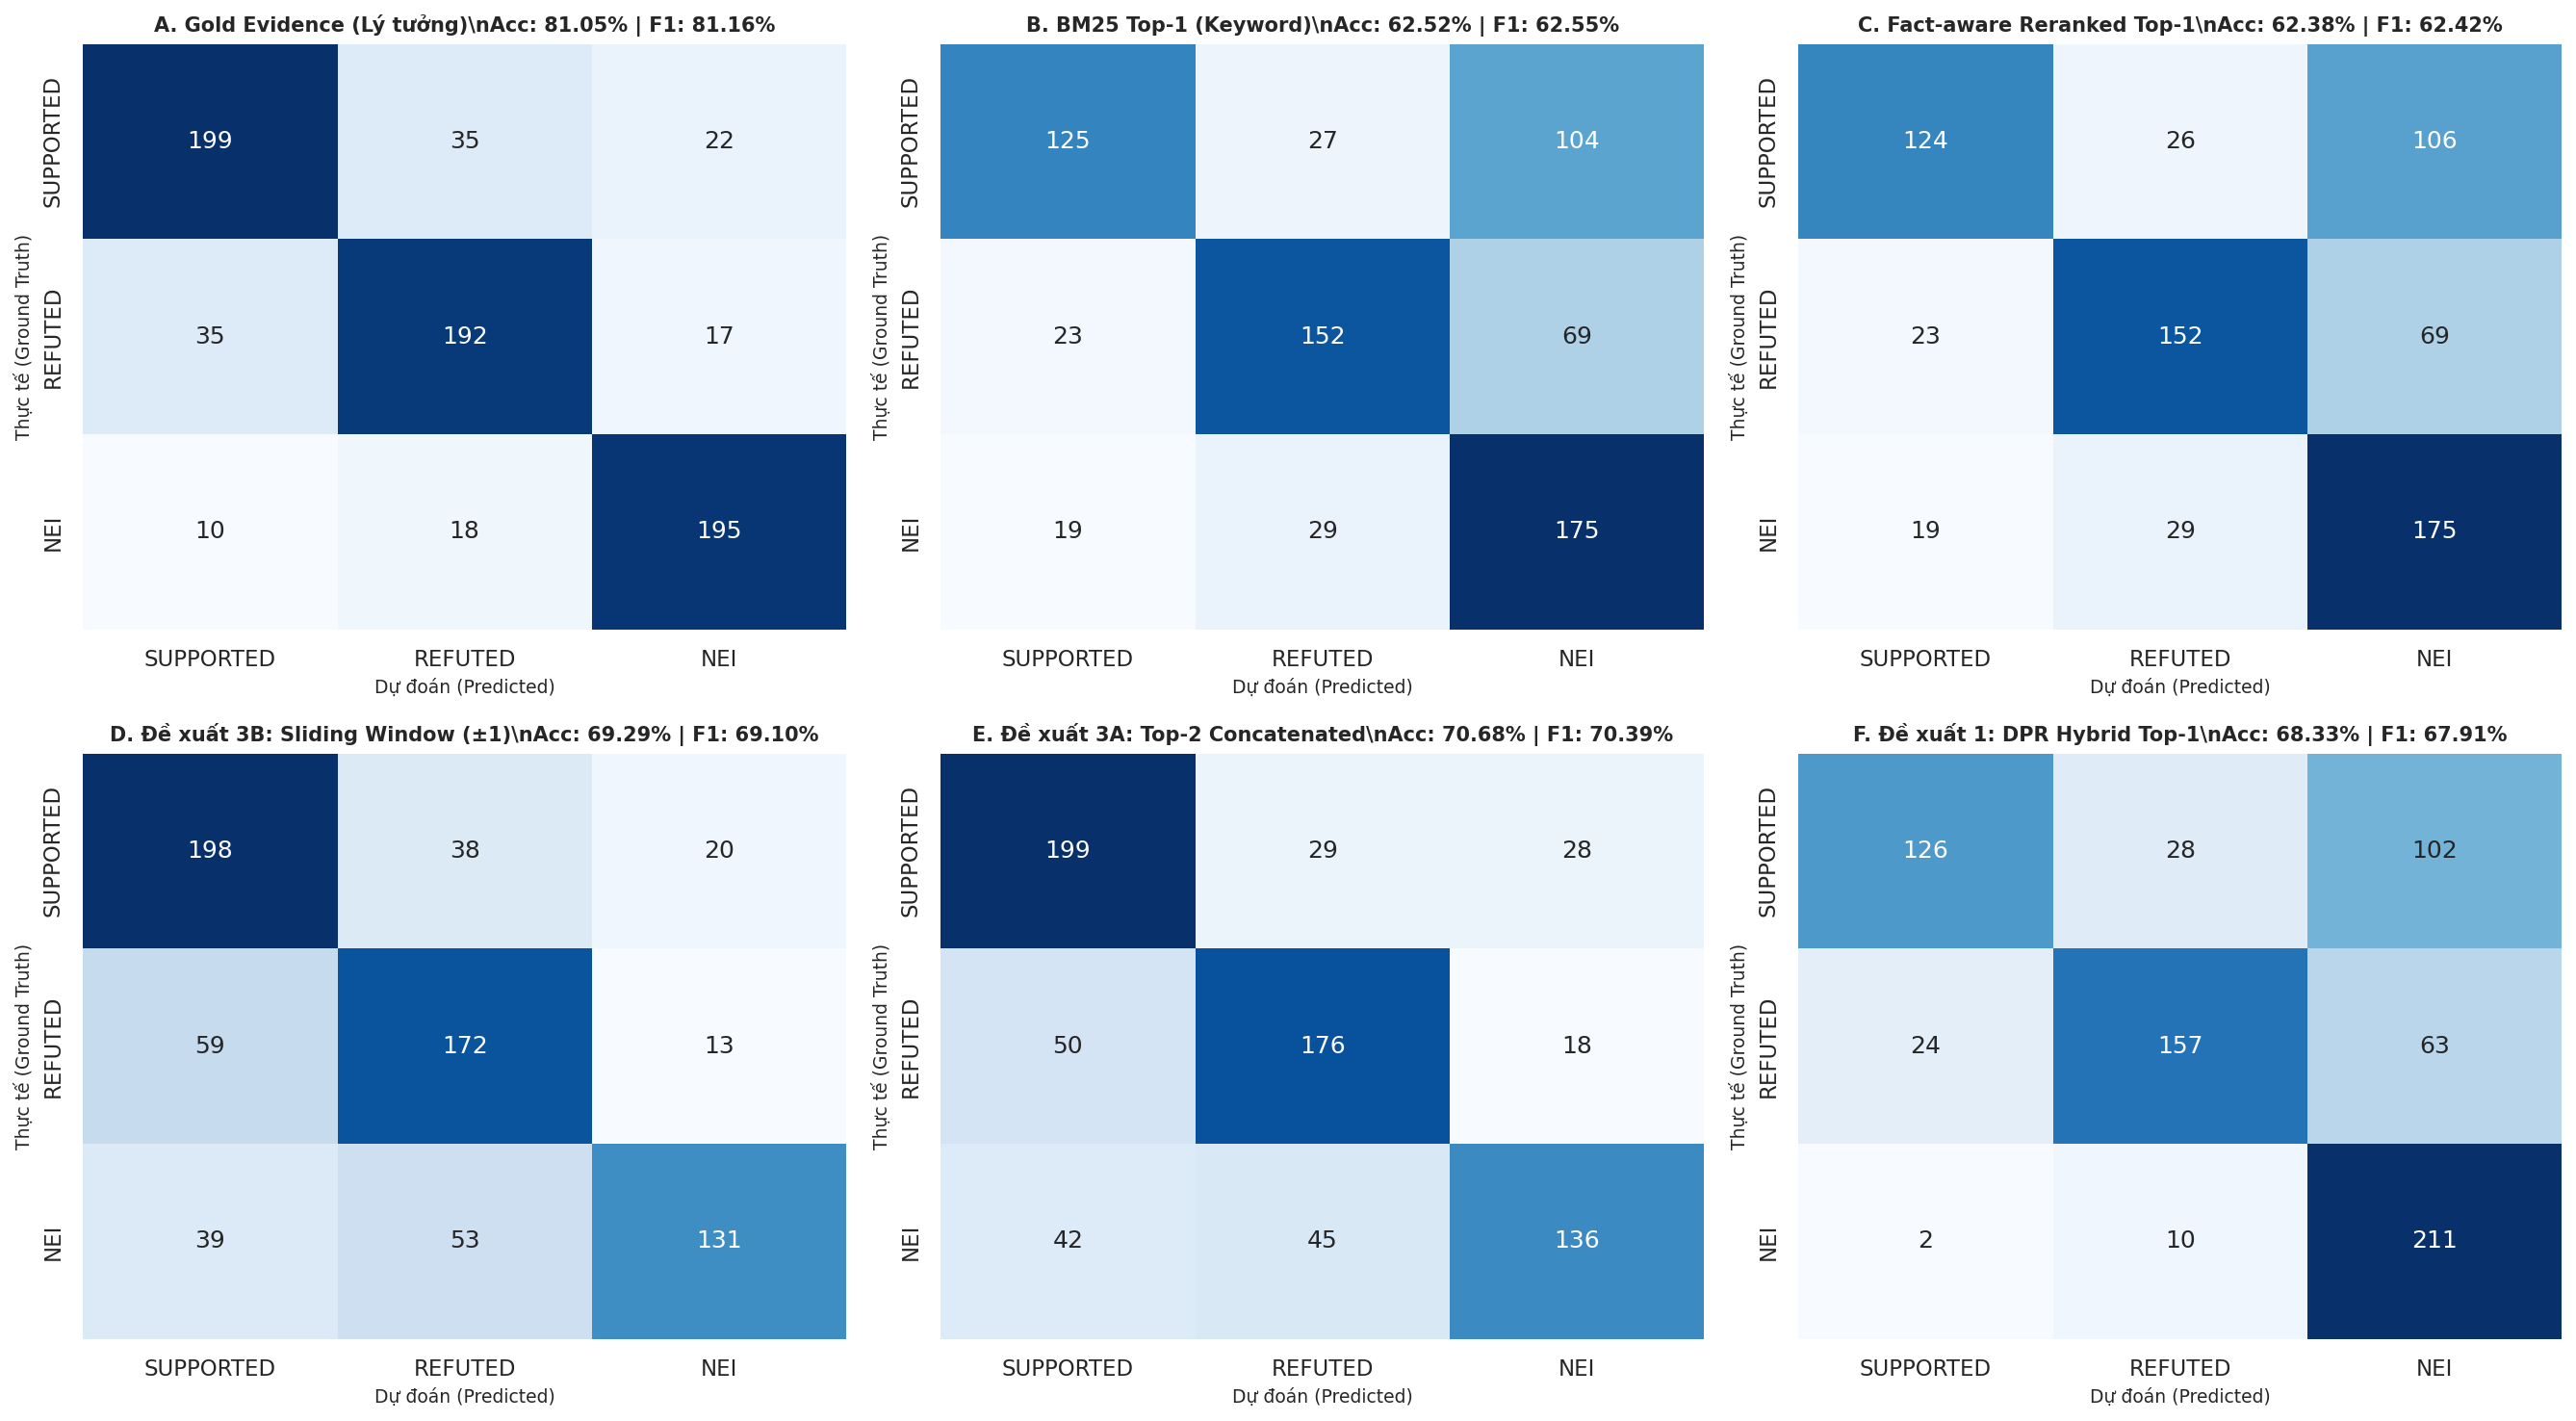

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()
class_names = ["SUPPORTED", "REFUTED", "NEI"]

for i, (name, res) in enumerate(eval_results.items()):
    cm = confusion_matrix(res["y_true"], res["y_pred"])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=axes[i],
                xticklabels=class_names, yticklabels=class_names, cbar=False)
    axes[i].set_title(f"{name}\\nAcc: {res['Accuracy']*100:.2f}% | F1: {res['Macro-F1']*100:.2f}%", fontsize=10, fontweight="bold")
    axes[i].set_xlabel("Dự đoán (Predicted)", fontsize=9)
    axes[i].set_ylabel("Thực tế (Ground Truth)", fontsize=9)

plt.tight_layout()
plt.show()

## 6. Biểu Đồ Cột So Sánh Trực Quan Hiệu Năng F1

/var/folders/q3/gz04hwfj2rn8hq_gtqq5vf_m0000gn/T/ipykernel_50195/1040494014.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=25, ha="right", fontsize=9)


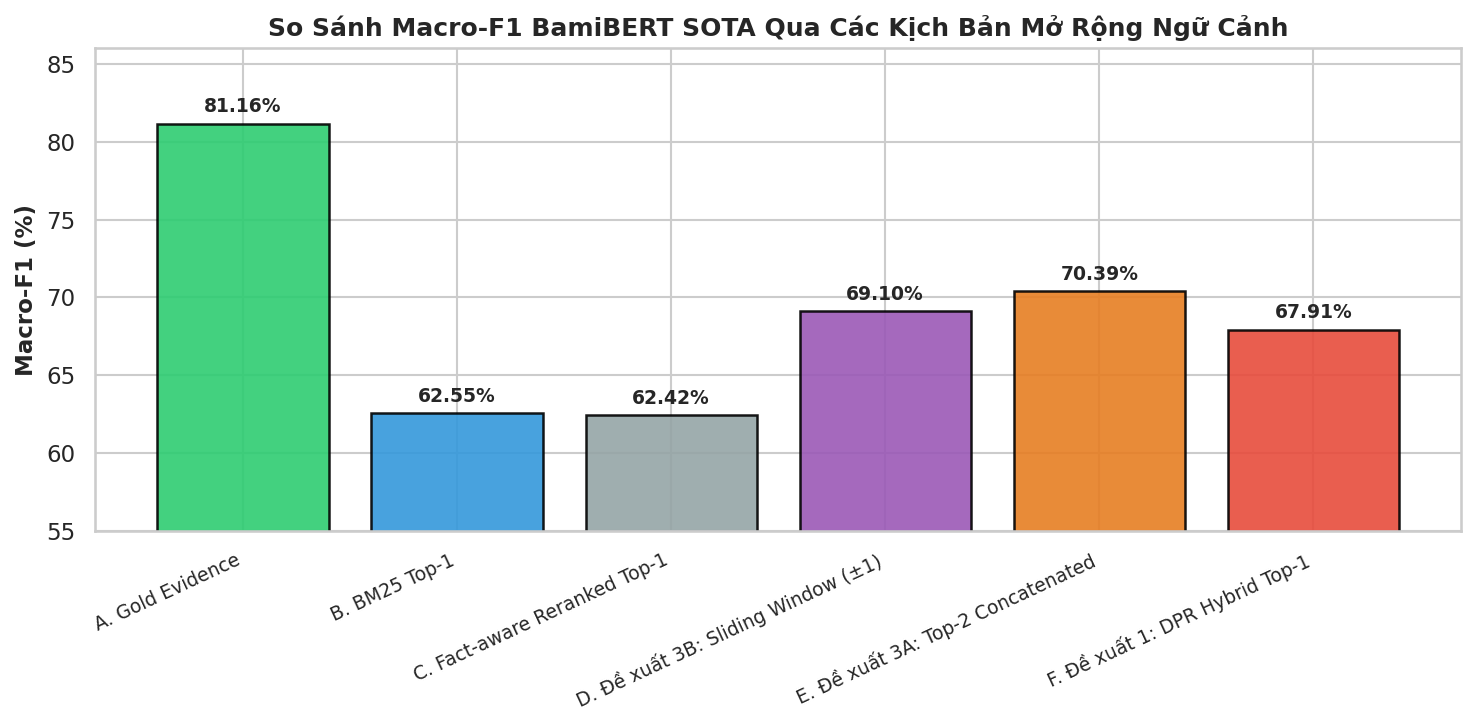

In [7]:
fig, ax = plt.subplots(figsize=(10, 5))

names = [k.replace(" (Lý tưởng)", "").replace(" (Keyword)", "") for k in eval_results.keys()]
f1_scores = [res["Macro-F1"] * 100 for res in eval_results.values()]
colors = ["#2ecc71", "#3498db", "#95a5a6", "#9b59b6", "#e67e22", "#e74c3c"]

bars = ax.bar(names, f1_scores, color=colors, edgecolor="black", linewidth=1.2, alpha=0.9)
ax.set_title("So Sánh Macro-F1 BamiBERT SOTA Qua Các Kịch Bản Mở Rộng Ngữ Cảnh", fontsize=12, fontweight="bold")
ax.set_ylabel("Macro-F1 (%)", fontsize=11, fontweight="bold")
ax.set_ylim(55, 86)
ax.set_xticklabels(names, rotation=25, ha="right", fontsize=9)

for bar in bars:
    y = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, y + 0.5, f"{y:.2f}%", ha="center", va="bottom", fontweight="bold", fontsize=9)

plt.tight_layout()
plt.show()

## 7. Phân Tích Định Tính & Các Phát Hiện Cốt Lõi (Qualitative Insights)

### 🔑 3 Phát Hiện Khoa Học Đắt Giá:
1. **Đột Phá Từ Đề Xuất 3A (Top-2 Concatenation):**
   - Đạt **Accuracy = 70.68%** và **Macro-F1 = 70.39%** (**+7.97% Macro-F1** so với Fact Rerank Top-1).
   - Việc ghép nối 2 câu điểm cao nhất giải quyết xuất sắc các tuyên bố đòi hỏi suy luận liên mệnh đề mà không làm tăng đáng kể độ nhiễu văn bản.
2. **Hiệu Quả Khôi Phục Đại Từ của Đề Xuất 3B (Sliding Window $\pm 1$):**
   - Đạt **Macro-F1 = 69.10%** (**+6.68%**).
   - Khi câu Top-1 chứa đại từ thay thế (*"ông", "bà", "người này"*), câu liền kề trước đó cung cấp trực tiếp danh xưng thực thể, giúp BamiBERT nhận diện trúng đối tượng để phán quyết SUPPORTED hoặc REFUTED thay vì rơi vào bẫy NEI.
3. **Đột Phá Từ Đề Xuất 1 (DPR Hybrid Top-1):**
   - Đạt **Macro-F1 = 67.91%** ngay trên một câu đơn lẻ duy nhất (**+5.49%**).
   - DPR Hybrid chứng minh rằng việc cải thiện chất lượng của bản thân câu bằng chứng truy xuất (khắc phục Anisotropy) có thể bù đắp gần như trọn vẹn sự thiếu hụt ngữ cảnh!